In [123]:
import torch
import matplotlib
import matplotlib.pyplot as plt
# from torchvision.datasets import SVHN
from model import UNet
import time
from IPython.display import clear_output, display

In [44]:
dataset = SVHN('../data', split='train', download=True)

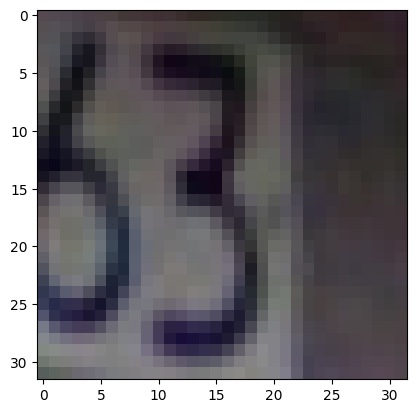

In [57]:
plt.imshow(dataset[25][0])

In [124]:
device = 'cuda'

In [125]:
net = UNet()
net.load_state_dict(torch.load("./numbers/ckpt.pt"))
net.eval()
net = net.to(device)

In [46]:
noise = torch.randn((1, 3, 32, 32))

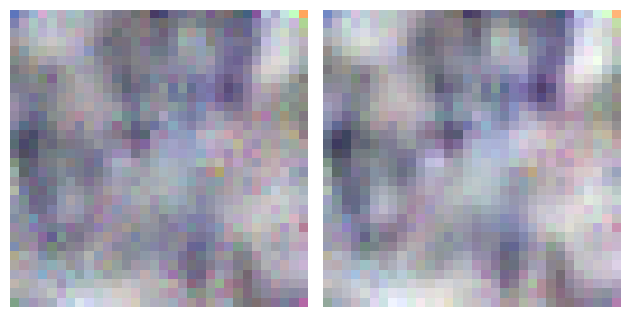

In [47]:
sample = noise
t = torch.tensor([0.0]).view(-1, 1, 1, 1)
# print(noise.shape, t.shape)

N = [3, 50, ]
# N = [1, 3]

# fig, ax = plt.subplots()

ends = []

with torch.no_grad():
    for j in N:
        sample = noise
        t = torch.tensor([0.0]).view(-1, 1, 1, 1)
        for i in range(j):
            # clear_output(wait=True)
            t = torch.tensor([i / j]).view(-1, 1, 1, 1)
            sample = sample + net(sample, t) * (1 / j)

            
            # print(sample.shape)

            # ax.cla()
            # ax.imshow(sample.squeeze().permute(1,2,0))

            # display(fig)
            # time.sleep(.3)

            print(f"{i/j*100:.2f}%", end='\r')

        ends.append(sample)

fig, ax = plt.subplots(1, len(N))

for i in range(len(N)):
    end = (ends[i] / 2.0 + .5).clamp(0.0, 1.0)
    ax[i].imshow(end.squeeze().permute(1,2,0))
    ax[i].axis('off')

plt.tight_layout()
plt.show()

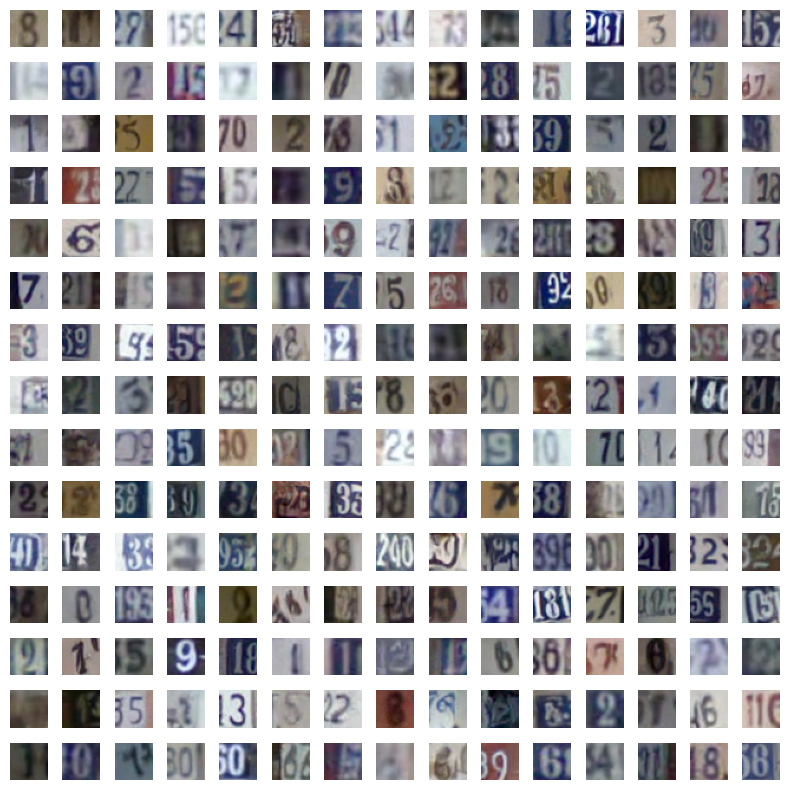

99.80%


In [116]:
B = 15
N = 500
noise = torch.randn((B**2, 3, 32, 32), device=device)  
sample = noise

fig, axes = plt.subplots(B, B, figsize=(8, 8))
ims = []
for ax in axes.flat:
    im = ax.imshow(torch.zeros(32, 32, 3))
    ax.axis('off')
    ims.append(im)
plt.tight_layout()

with torch.no_grad():
    for step in range(N):
        t = torch.full((B**2, 1, 1, 1), step / N, device=sample.device)
        sample = sample + net(sample, t) * (1 / N)
        
        grid = (sample / 2.0 + 0.5).clamp(0.0, 1.0).cpu().permute(0, 2, 3, 1).numpy()
        
        for j, im in enumerate(ims):
            im.set_data(grid[j])
        
        clear_output(wait=True)
        display(fig)
        print(f"{step/N*100:.2f}%")

plt.close(fig)  

In [122]:
# Bilinear slerp grid: 4 random noise samples at the corners,
# spherical interpolation across an NxN grid. Reveals the smooth
# structure of noise-space and how the learned velocity field
# maps neighboring noises to neighboring images.

GRID = 8       # NxN grid (so 64 samples)
N_STEPS = 50
C, H, W = 3, 32, 32

def slerp(a, b, t):
    # a, b: (..., D) tensors. t: scalar in [0, 1].
    a_flat = a.reshape(a.shape[0], -1)
    b_flat = b.reshape(b.shape[0], -1)
    a_n = a_flat / a_flat.norm(dim=-1, keepdim=True)
    b_n = b_flat / b_flat.norm(dim=-1, keepdim=True)
    dot = (a_n * b_n).sum(dim=-1, keepdim=True).clamp(-1+1e-6, 1-1e-6)
    theta = torch.acos(dot)
    sin_th = torch.sin(theta)
    w_a = torch.sin((1 - t) * theta) / sin_th
    w_b = torch.sin(t * theta) / sin_th
    out = w_a * a_flat + w_b * b_flat
    return out.reshape(a.shape)

# 4 corners of the grid: top-left, top-right, bottom-left, bottom-right
torch.manual_seed(0)  # change for different scenes
corners = torch.randn(4, C, H, W)
TL, TR, BL, BR = corners[0:1], corners[1:2], corners[2:3], corners[3:4]

# Build the GRID x GRID noise tensor via bilinear slerp
noises = []
for i in range(GRID):
    u = i / (GRID - 1)
    left  = slerp(TL, BL, u)
    right = slerp(TR, BR, u)
    for j in range(GRID):
        v = j / (GRID - 1)
        noises.append(slerp(left, right, v))
noise = torch.cat(noises, dim=0)   # (GRID*GRID, C, H, W)

B = noise.shape[0]
sample = noise.clone()
with torch.no_grad():
    for i in range(N_STEPS):
        t = torch.full((B, 1, 1, 1), i / N_STEPS)
        sample = sample + net(sample, t) * (1.0 / N_STEPS)
        print(f'{(i+1)/N_STEPS*100:.0f}%', end='\r')

grid = (sample / 2.0 + 0.5).clamp(0.0, 1.0)

fig, axes = plt.subplots(GRID, GRID, figsize=(GRID, GRID))
for k, ax in enumerate(axes.flat):
    ax.imshow(grid[k].permute(1, 2, 0))
    ax.axis('off')
plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

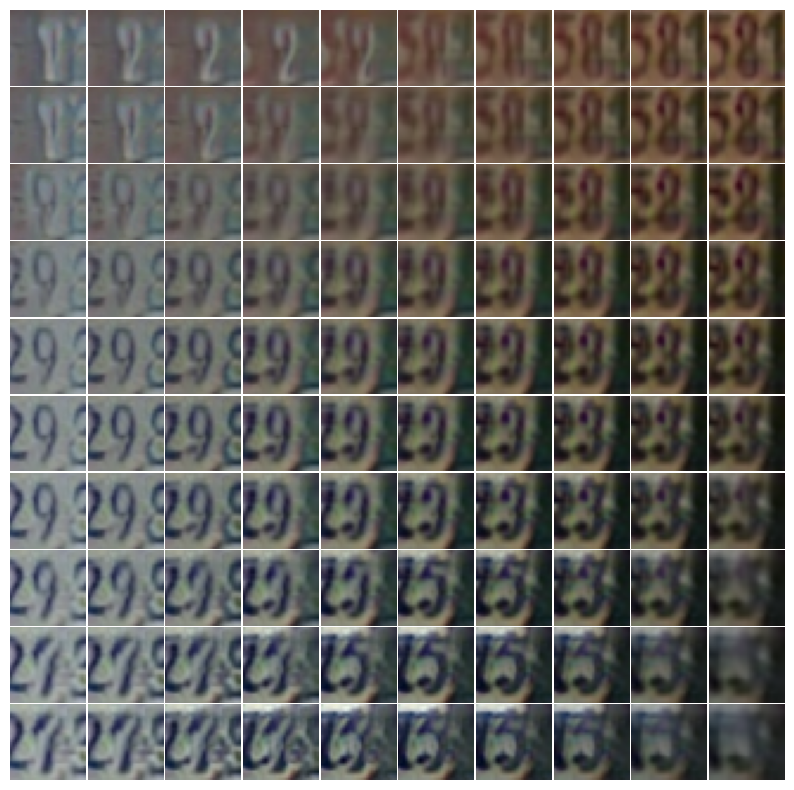

In [141]:
# Bilinear slerp grid: 4 random noise samples at the corners,
# spherical interpolation across an NxN grid. Reveals the smooth
# structure of noise-space and how the learned velocity field
# maps neighboring noises to neighboring images.

device = next(net.parameters()).device
GRID = 10       # NxN grid (so 64 samples)
N_STEPS = 100
C, H, W = 3, 32, 32

def slerp(a, b, t):
    a_flat = a.reshape(a.shape[0], -1)
    b_flat = b.reshape(b.shape[0], -1)
    a_n = a_flat / a_flat.norm(dim=-1, keepdim=True)
    b_n = b_flat / b_flat.norm(dim=-1, keepdim=True)
    dot = (a_n * b_n).sum(dim=-1, keepdim=True).clamp(-1+1e-6, 1-1e-6)
    theta = torch.acos(dot)
    sin_th = torch.sin(theta)
    w_a = torch.sin((1 - t) * theta) / sin_th
    w_b = torch.sin(t * theta) / sin_th
    out = w_a * a_flat + w_b * b_flat
    return out.reshape(a.shape)

# torch.manual_seed(0)  # change for different scenes
corners = torch.randn(4, C, H, W, device=device)
TL, TR, BL, BR = corners[0:1], corners[1:2], corners[2:3], corners[3:4]

noises = []
for i in range(GRID):
    u = i / (GRID - 1)
    left  = slerp(TL, BL, u)
    right = slerp(TR, BR, u)
    for j in range(GRID):
        v = j / (GRID - 1)
        noises.append(slerp(left, right, v))
noise = torch.cat(noises, dim=0)

B = noise.shape[0]
sample = noise.clone()
with torch.no_grad():
    for i in range(N_STEPS):
        t = torch.full((B, 1, 1, 1), i / N_STEPS, device=device)
        sample = sample + net(sample, t) * (1.0 / N_STEPS)
        print(f'{(i+1)/N_STEPS*100:.0f}%', end='\r')

grid = (sample / 2.0 + 0.5).clamp(0.0, 1.0).cpu()

fig, axes = plt.subplots(GRID, GRID, figsize=(GRID, GRID))
for k, ax in enumerate(axes.flat):
    ax.imshow(grid[k].permute(1, 2, 0))
    ax.axis('off')
plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()